In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from ISLP import load_data
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

x = [ -3.61549993  13.63192272 -11.13468092 ...   9.69589223  -4.83282652
   9.8427423 ]
mean = -0.07181442043805765   std = 9.943452860448089


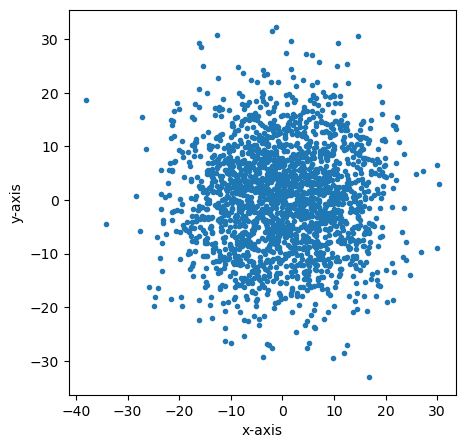

In [84]:
# generate 2d normal distributed samples

fig, ax = plt.subplots(figsize = (5, 5))
x = np.random.normal(loc = 0, scale = 10, size = 2000)
print("x =", x)
print("mean =", np.mean(x), "  std =", np.std(x))
y = np.random.normal(loc = 0, scale = 10, size = 2000)

ax.set_xlabel("x-axis")
ax.set_ylabel("y-axis")
ax.plot(x, y, ".");

2.828501789372064 1.988149218631162
2.828501789372064 [1.98814922]


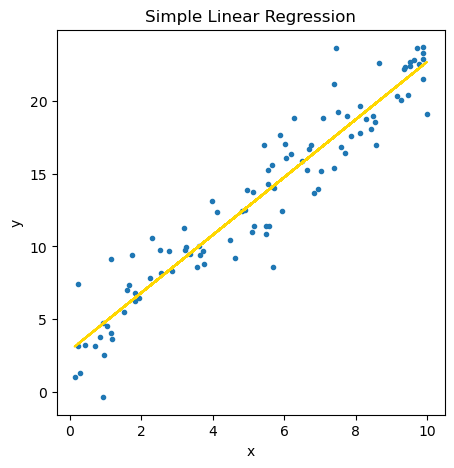

In [85]:
# linear regression on simulated data

x = np.random.uniform(0, 10, size=100)
eps = np.random.normal(0, 2, size=100)
y = 3 + 2 * x + eps

fig, ax = plt.subplots(figsize = (5, 5))
ax.plot(x, y, '.')

x_bar = x.mean()
y_bar = y.mean()

beta1_hat = sum((x - x_bar) * (y - y_bar)) / sum((x - x_bar) ** 2)
beta0_hat = y_bar - beta1_hat * x_bar

y_hat = beta1_hat * x + beta0_hat
ax.plot(x, y_hat, color="gold")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Simple Linear Regression")

# check using sklearn

model = LinearRegression()
model.fit(x.reshape(-1, 1), y)
print(beta0_hat, beta1_hat)
print(model.intercept_, model.coef_)


In [86]:
# errors

RSS = sum((y - y_hat) ** 2)
RSE = np.sqrt(RSS / (len(x) - 2))   # residual standard error
R2 = 1 - RSS / sum((y - y_bar) ** 2)

print(RSE, R2)
print(mean_squared_error(y, y_hat), r2_score(y, y_hat))

1.957171546026574 0.9032299339325169
3.7539100513645276 0.903229933932517


slope = [-0.15784473]
R^2 = 0.6059482578894348


Text(0, 0.5, 'mpg')

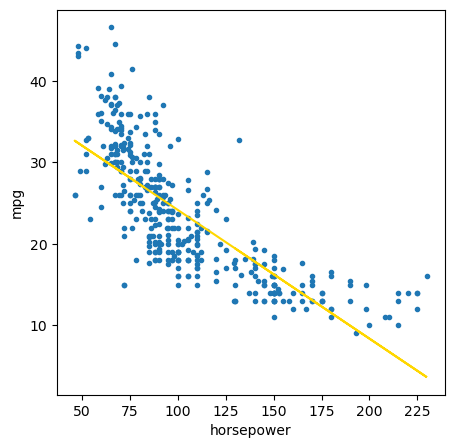

In [ ]:
# Auto example from ISLP

auto = load_data("Auto")
X = auto[["horsepower"]]
y = auto["mpg"]

model = LinearRegression()
model.fit(X, y)
print("slope =", model.coef_)
print("R^2 =", model.score(X, y))    # R^2

fig, ax = plt.subplots(figsize = (5, 5))
ax.plot(X, y, '.')
ax.plot(X, model.predict(X), color="gold")
ax.set_xlabel("horsepower")
ax.set_ylabel("mpg")

coef = [-0.46618963  0.00123054]
R^2 = 0.6875590305127516


Text(0, 0.5, 'mpg')

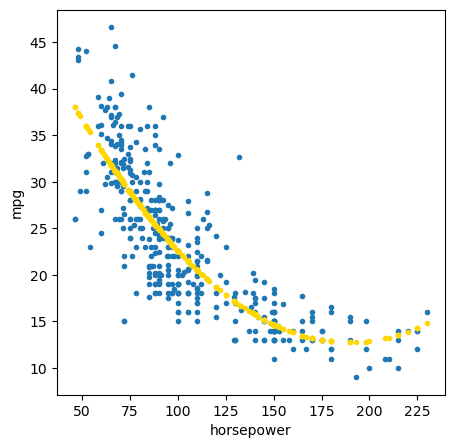

In [103]:
X_poly = pd.DataFrame({"horsepower" : auto["horsepower"],
                       "horsepower^2": auto["horsepower"] ** 2})

y = auto["mpg"]
model = LinearRegression()
model.fit(X_poly, y)
print("coef =", model.coef_)
print("R^2 =", model.score(X_poly, y)) 

fig, ax = plt.subplots(figsize = (5, 5))
ax.plot(X, y, '.')

ax.plot(X, model.predict(X_poly), ".", color="gold")
ax.set_xlabel("horsepower")
ax.set_ylabel("mpg")

In [109]:
X_interact = auto[["horsepower", "weight"]].copy()
X_interact["horsepower*weight"] = \
    X_interact["horsepower"] * X_interact["weight"]

model.fit(X_interact, y)
print("coef =", model.coef_)
print("R^2 =", model.score(X_interact, y)) 

import statsmodels.formula.api as smf

est = smf.ols(formula="mpg ~ horsepower * weight", data=auto).fit()
print(est.summary())

coef = [-2.50838171e-01 -1.07724112e-02  5.35537776e-05]
R^2 = 0.748435145025321
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     384.8
Date:                Sat, 18 Jul 2026   Prob (F-statistic):          7.26e-116
Time:                        13:26:13   Log-Likelihood:                -1090.7
No. Observations:                 392   AIC:                             2189.
Df Residuals:                     388   BIC:                             2205.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------